# Parking Availability Analysis for Lot 643

This notebook analyzes the training data to understand parking availability patterns and explore relationships between weather conditions and parking availability.

## Analysis Objectives:
- Availability patterns over hours, days, and months
- Weather impact on parking availability
- Correlation analysis between weather variables and free spaces
- Time series visualization of trends

## 1. Import Required Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sqlalchemy import create_engine
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from datetime import datetime
import plotly.figure_factory as ff

# Set style for matplotlib
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Database Connection Setup

In [2]:
# Database connection setup
# Update these connection parameters to match your database
DB_HOST = "141.13.162.160"
DB_NAME = "parking"
DB_USER = "aostadi"
DB_PASSWORD = "7PLKxvt1uf8m3Zzz"
DB_PORT = "5432"

# Create SQLAlchemy engine
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

print("Database connection established!")

Database connection established!


## 3. Fetch Training Data from Database

In [3]:
# Fetch training data from the database
query = """
SELECT 
    hour_timestamp,
    parking_lot_id,
    avg_free_spaces,
    min_free_spaces,
    max_free_spaces,
    free_spaces_range,
    hour_of_day,
    day_of_week,
    weekday_name,
    day_of_month,
    calendar_week,
    month_number,
    month_name,
    temperature_2m,
    relative_humidity_2m,
    precipitation,
    day_type,
    time_period,
    temperature_category,
    precipitation_category
FROM ali_training_data_hourly_availability_hourly_lot634
ORDER BY hour_timestamp;
"""

print("Fetching data from database...")
df = pd.read_sql_query(query, engine)
print(f"Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['hour_timestamp'].min()} to {df['hour_timestamp'].max()}")

# Display first few rows
df.head()

Fetching data from database...
Data loaded successfully!
Dataset shape: (9937, 20)
Date range: 2024-10-12 00:00:00+00:00 to 2025-11-30 00:00:00+00:00


,hour_timestamp,parking_lot_id,avg_free_spaces,min_free_spaces,max_free_spaces,free_spaces_range,hour_of_day,day_of_week,weekday_name,day_of_month,calendar_week,month_number,month_name,temperature_2m,relative_humidity_2m,precipitation,day_type,time_period,temperature_category,precipitation_category
0,2024-10-12 00:00:00+00:00,634,64.0,64,64,0.0,0.0,6.0,Saturday,12.0,41.0,10.0,October,5.0,90.0,0.0,Weekend,Night,Cold,No Rain
1,2024-10-12 01:00:00+00:00,634,64.0,64,64,0.0,1.0,6.0,Saturday,12.0,41.0,10.0,October,4.3,93.0,0.0,Weekend,Night,Cold,No Rain
2,2024-10-12 02:00:00+00:00,634,64.0,64,64,0.0,2.0,6.0,Saturday,12.0,41.0,10.0,October,4.2,93.0,0.0,Weekend,Night,Cold,No Rain
3,2024-10-12 03:00:00+00:00,634,64.0,64,64,0.0,3.0,6.0,Saturday,12.0,41.0,10.0,October,4.2,92.0,0.0,Weekend,Night,Cold,No Rain
4,2024-10-12 04:00:00+00:00,634,64.0,64,64,0.0,4.0,6.0,Saturday,12.0,41.0,10.0,October,4.4,92.0,0.0,Weekend,Night,Cold,No Rain


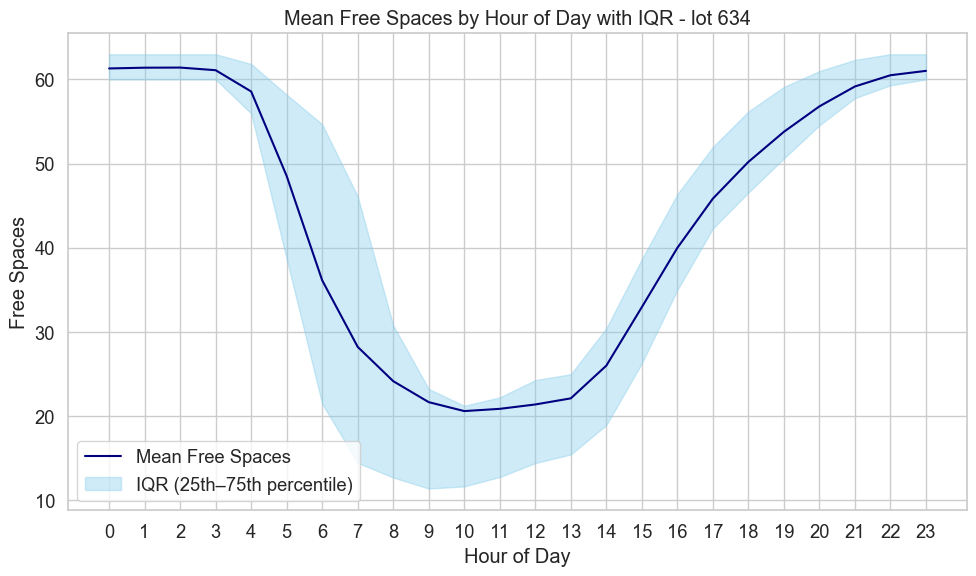

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume df is your DataFrame with columns: 'timestamp' and 'free_spaces'
df['hour'] = pd.to_datetime(df['hour_timestamp']).dt.hour

# Group by hour and calculate statistics
grouped = df.groupby('hour')['avg_free_spaces']
mean = grouped.mean()
q25 = grouped.quantile(0.25)
q75 = grouped.quantile(0.75)

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid", font_scale=1.2)
plt.plot(mean.index, mean.values, label='Mean Free Spaces', color='navy')
plt.fill_between(mean.index, q25.values, q75.values, color='skyblue', alpha=0.4, label='IQR (25th–75th percentile)')
plt.xlabel('Hour of Day')
plt.ylabel('Free Spaces')
plt.title('Mean Free Spaces by Hour of Day with IQR - lot 634')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Cleaning

In [5]:
# Data preprocessing and cleaning
print("Dataset Info:")
print("="*50)
print(df.info())
print("\nMissing Values:")
print("="*50)
print(df.isnull().sum())

# Convert timestamp to datetime if not already
df['hour_timestamp'] = pd.to_datetime(df['hour_timestamp'])

# Extract additional time features
df['date'] = df['hour_timestamp'].dt.date
df['month_year'] = df['hour_timestamp'].dt.to_period('M')
df['week_year'] = df['hour_timestamp'].dt.to_period('W')

# Clean string columns
df['weekday_name'] = df['weekday_name'].str.strip()
df['month_name'] = df['month_name'].str.strip()
df['temperature_category'] = df['temperature_category'].str.strip()
df['precipitation_category'] = df['precipitation_category'].str.strip()

print("\nData Types after preprocessing:")
print("="*50)
print(df.dtypes)

print(f"\nUnique values in categorical columns:")
print(f"Day Type: {df['day_type'].unique()}")
print(f"Time Period: {df['time_period'].unique()}")
print(f"Temperature Category: {df['temperature_category'].unique()}")
print(f"Precipitation Category: {df['precipitation_category'].unique()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9937 entries, 0 to 9936
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   hour_timestamp          9937 non-null   datetime64[ns, UTC]
 1   parking_lot_id          9937 non-null   int64              
 2   avg_free_spaces         9937 non-null   float64            
 3   min_free_spaces         9937 non-null   int64              
 4   max_free_spaces         9937 non-null   int64              
 5   free_spaces_range       9937 non-null   float64            
 6   hour_of_day             9937 non-null   float64            
 7   day_of_week             9937 non-null   float64            
 8   weekday_name            9937 non-null   object             
 9   day_of_month            9937 non-null   float64            
 10  calendar_week           9937 non-null   float64            
 11  month_number            9937 

## 5. Availability Analysis by Hours

In [6]:
# Hourly availability analysis
hourly_stats = df.groupby('hour_of_day').agg({
    'avg_free_spaces': ['mean', 'std', 'min', 'max'],
    'min_free_spaces': 'mean',
    'max_free_spaces': 'mean'
}).round(2)

# Flatten column names
hourly_stats.columns = ['avg_mean', 'avg_std', 'avg_min', 'avg_max', 'min_avg', 'max_avg']
hourly_stats.reset_index(inplace=True)

print("Hourly Availability Statistics:")
print(hourly_stats)

# Create hourly availability plot
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=('Average Free Spaces by Hour', 'Min/Max Range by Hour'),
                    vertical_spacing=0.15)

# Average free spaces
fig.add_trace(go.Scatter(
    x=hourly_stats['hour_of_day'],
    y=hourly_stats['avg_mean'],
    mode='lines+markers',
    name='Average Free Spaces',
    line=dict(color='blue', width=3)
), row=1, col=1)

# Error bands for standard deviation
fig.add_trace(go.Scatter(
    x=hourly_stats['hour_of_day'],
    y=hourly_stats['avg_mean'] + hourly_stats['avg_std'],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=hourly_stats['hour_of_day'],
    y=hourly_stats['avg_mean'] - hourly_stats['avg_std'],
    mode='lines',
    line=dict(width=0),
    fill='tonexty',
    fillcolor='rgba(0,100,80,0.2)',
    name='±1 Std Dev',
    hoverinfo='skip'
), row=1, col=1)

# Min/Max range
fig.add_trace(go.Scatter(
    x=hourly_stats['hour_of_day'],
    y=hourly_stats['min_avg'],
    mode='lines+markers',
    name='Average Min',
    line=dict(color='red', width=2)
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=hourly_stats['hour_of_day'],
    y=hourly_stats['max_avg'],
    mode='lines+markers',
    name='Average Max',
    line=dict(color='green', width=2)
), row=2, col=1)

fig.update_layout(
    title='Parking Availability Patterns by Hour of Day',
    height=600,
    showlegend=True
)

fig.update_xaxes(title_text="Hour of Day", row=2, col=1)
fig.update_yaxes(title_text="Free Spaces", row=1, col=1)
fig.update_yaxes(title_text="Free Spaces", row=2, col=1)

fig.show()

Hourly Availability Statistics:
    hour_of_day  avg_mean  avg_std  avg_min  avg_max  min_avg  max_avg
0           0.0     61.31     3.41    14.00     64.0    61.19    61.39
1           1.0     61.40     3.35    14.00     64.0    61.29    61.47
2           2.0     61.42     3.31    14.00     64.0    61.24    61.50
3           3.0     61.10     3.31    14.00     64.0    60.39    61.42
4           4.0     58.57     4.52    12.17     64.0    55.62    60.48
5           5.0     48.52    12.37     3.47     64.0    42.28    55.72
6           6.0     36.11    16.95     0.97     64.0    30.51    42.57
7           7.0     28.19    18.20     0.37     64.0    25.37    31.14
8           8.0     24.12    16.93     1.27     64.0    21.89    26.57
9           9.0     21.62    15.69     1.08     64.0    19.73    23.69
10         10.0     20.56    14.12     1.00     64.0    18.67    22.78
11         11.0     20.83    12.77     2.12     64.0    18.43    23.46
12         12.0     21.35    11.37    -0.77  

## 6. Availability Analysis by Days

In [7]:
# Daily availability analysis
daily_stats = df.groupby(['day_of_week', 'weekday_name']).agg({
    'avg_free_spaces': ['mean', 'std', 'count']
}).round(2)

daily_stats.columns = ['mean_free_spaces', 'std_free_spaces', 'sample_count']
daily_stats.reset_index(inplace=True)

print("Daily Availability Statistics:")
print(daily_stats)

# Day type analysis (Weekday vs Weekend)
day_type_stats = df.groupby('day_type').agg({
    'avg_free_spaces': ['mean', 'std'],
    'temperature_2m': 'mean',
    'precipitation': 'mean'
}).round(2)

day_type_stats.columns = ['avg_free_spaces', 'std_free_spaces', 'avg_temp', 'avg_precip']
day_type_stats.reset_index(inplace=True)

print("\nWeekday vs Weekend Analysis:")
print(day_type_stats)

# Create daily plots
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Average Free Spaces by Day of Week', 'Weekday vs Weekend Comparison'),
                    horizontal_spacing=0.15)

# Days of week
fig.add_trace(go.Bar(
    x=daily_stats['weekday_name'],
    y=daily_stats['mean_free_spaces'],
    error_y=dict(type='data', array=daily_stats['std_free_spaces']),
    name='Free Spaces by Day',
    marker_color='skyblue'
), row=1, col=1)

# Weekday vs Weekend
fig.add_trace(go.Bar(
    x=day_type_stats['day_type'],
    y=day_type_stats['avg_free_spaces'],
    error_y=dict(type='data', array=day_type_stats['std_free_spaces']),
    name='Weekday vs Weekend',
    marker_color='lightcoral'
), row=1, col=2)

fig.update_layout(
    title='Parking Availability Analysis by Days',
    height=400,
    showlegend=True
)

fig.update_xaxes(title_text="Day of Week", row=1, col=1)
fig.update_xaxes(title_text="Day Type", row=1, col=2)
fig.update_yaxes(title_text="Average Free Spaces", row=1, col=1)
fig.update_yaxes(title_text="Average Free Spaces", row=1, col=2)

fig.show()

Daily Availability Statistics:
   day_of_week weekday_name  mean_free_spaces  std_free_spaces  sample_count
0          0.0       Sunday             53.35            10.88          1417
1          1.0       Monday             41.75            20.56          1416
2          2.0      Tuesday             40.82            20.97          1416
3          3.0    Wednesday             41.69            20.36          1416
4          4.0     Thursday             40.86            20.36          1416
5          5.0       Friday             40.59            18.24          1416
6          6.0     Saturday             42.34            17.99          1440

Weekday vs Weekend Analysis:
  day_type  avg_free_spaces  std_free_spaces  avg_temp  avg_precip
0  Weekday            41.14            20.12     10.15        0.08
1  Weekend            47.80            15.88     10.22        0.07


## 7. Availability Analysis by Months

In [8]:
# Monthly availability analysis
monthly_stats = df.groupby(['month_number', 'month_name']).agg({
    'avg_free_spaces': ['mean', 'std'],
    'temperature_2m': 'mean',
    'precipitation': 'mean'
}).round(2)

monthly_stats.columns = ['avg_free_spaces', 'std_free_spaces', 'avg_temp', 'avg_precip']
monthly_stats.reset_index(inplace=True)

print("Monthly Availability Statistics:")
print(monthly_stats)

# Time series by month
monthly_trend = df.groupby('month_year').agg({
    'avg_free_spaces': 'mean',
    'temperature_2m': 'mean',
    'precipitation': 'mean'
}).round(2)

monthly_trend.reset_index(inplace=True)
monthly_trend['month_year_str'] = monthly_trend['month_year'].astype(str)

print("\nMonthly Trend Over Time:")
print(monthly_trend)

# Create monthly analysis plots
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=('Monthly Average Free Spaces', 'Monthly Temperature & Precipitation',
                                  'Time Series Trend', 'Monthly Variability'),
                    vertical_spacing=0.15, horizontal_spacing=0.1)

# Monthly averages
fig.add_trace(go.Bar(
    x=monthly_stats['month_name'],
    y=monthly_stats['avg_free_spaces'],
    name='Free Spaces',
    marker_color='lightblue'
), row=1, col=1)

# Temperature and precipitation by month
fig.add_trace(go.Scatter(
    x=monthly_stats['month_name'],
    y=monthly_stats['avg_temp'],
    mode='lines+markers',
    name='Temperature (°C)',
    line=dict(color='red'),
    yaxis='y2'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=monthly_stats['month_name'],
    y=monthly_stats['avg_precip'],
    name='Precipitation (mm)',
    marker_color='blue',
    opacity=0.6
), row=1, col=2)

# Time series trend
if len(monthly_trend) > 1:
    fig.add_trace(go.Scatter(
        x=monthly_trend['month_year_str'],
        y=monthly_trend['avg_free_spaces'],
        mode='lines+markers',
        name='Monthly Trend',
        line=dict(color='green', width=3)
    ), row=2, col=1)

# Monthly variability (box plot data preparation)
fig.add_trace(go.Box(
    y=df['avg_free_spaces'],
    x=df['month_name'],
    name='Monthly Distribution'
), row=2, col=2)

fig.update_layout(
    title='Parking Availability Monthly Analysis',
    height=800,
    showlegend=True
)

fig.update_xaxes(title_text="Month", row=1, col=1)
fig.update_xaxes(title_text="Month", row=1, col=2)
fig.update_xaxes(title_text="Month-Year", row=2, col=1)
fig.update_xaxes(title_text="Month", row=2, col=2)

fig.update_yaxes(title_text="Average Free Spaces", row=1, col=1)
fig.update_yaxes(title_text="Weather", row=1, col=2)
fig.update_yaxes(title_text="Average Free Spaces", row=2, col=1)
fig.update_yaxes(title_text="Free Spaces Distribution", row=2, col=2)

fig.show()

Monthly Availability Statistics:
    month_number month_name  avg_free_spaces  std_free_spaces  avg_temp  \
0            1.0    January            46.38            18.62      2.13   
1            2.0   February            43.26            20.19      1.32   
2            3.0      March            41.08            21.58      5.97   
3            4.0      April            39.09            21.47     11.16   
4            5.0        May            40.27            19.48     14.06   
5            6.0       June            46.53            16.21     20.37   
6            7.0       July            42.01            18.04     19.57   
7            8.0     August            42.76            17.00     19.36   
8            9.0  September            43.65            17.66     14.97   
9           10.0    October            43.17            19.01     10.49   
10          11.0   November            44.36            19.18      4.86   
11          12.0   December            42.89            20.52      

## 8. Weather Data Exploration

In [9]:
# Weather data exploration
print("Weather Statistics:")
print("="*50)
weather_stats = df[['temperature_2m', 'relative_humidity_2m', 'precipitation']].describe()
print(weather_stats)

print("\nWeather Category Distributions:")
print("="*50)
print("Temperature Categories:")
print(df['temperature_category'].value_counts())
print("\nPrecipitation Categories:")
print(df['precipitation_category'].value_counts())

# Weather distribution plots
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=('Temperature Distribution', 'Humidity Distribution',
                                  'Precipitation Distribution', 'Weather Categories'),
                    vertical_spacing=0.15, horizontal_spacing=0.1)

# Temperature histogram
fig.add_trace(go.Histogram(
    x=df['temperature_2m'],
    nbinsx=30,
    name='Temperature',
    marker_color='red',
    opacity=0.7
), row=1, col=1)

# Humidity histogram
fig.add_trace(go.Histogram(
    x=df['relative_humidity_2m'],
    nbinsx=30,
    name='Humidity',
    marker_color='blue',
    opacity=0.7
), row=1, col=2)

# Precipitation histogram (log scale for better visualization)
precipitation_data = df[df['precipitation'] > 0]['precipitation']  # Only non-zero values
if len(precipitation_data) > 0:
    fig.add_trace(go.Histogram(
        x=precipitation_data,
        nbinsx=20,
        name='Precipitation',
        marker_color='green',
        opacity=0.7
    ), row=2, col=1)

# Weather categories stacked bar
temp_cat_counts = df['temperature_category'].value_counts()
precip_cat_counts = df['precipitation_category'].value_counts()

fig.add_trace(go.Bar(
    x=temp_cat_counts.index,
    y=temp_cat_counts.values,
    name='Temperature Categories',
    marker_color='orange'
), row=2, col=2)

fig.update_layout(
    title='Weather Data Distribution',
    height=600,
    showlegend=True
)

fig.update_xaxes(title_text="Temperature (°C)", row=1, col=1)
fig.update_xaxes(title_text="Humidity (%)", row=1, col=2)
fig.update_xaxes(title_text="Precipitation (mm)", row=2, col=1)
fig.update_xaxes(title_text="Category", row=2, col=2)

fig.update_yaxes(title_text="Frequency", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=2)
fig.update_yaxes(title_text="Frequency", row=2, col=1)
fig.update_yaxes(title_text="Count", row=2, col=2)

fig.show()

Weather Statistics:
       temperature_2m  relative_humidity_2m  precipitation
count     9937.000000           9937.000000     9937.00000
mean        10.167566             75.856093        0.07936
std          7.946968             19.067482        0.35593
min         -8.100000             14.000000        0.00000
25%          3.800000             64.000000        0.00000
50%          9.700000             80.000000        0.00000
75%         15.600000             91.000000        0.00000
max         36.500000            100.000000        8.00000

Weather Category Distributions:
Temperature Categories:
Cold        4197
Mild        3252
Freezing     903
Warm         878
Hot          707
Name: temperature_category, dtype: int64

Precipitation Categories:
No Rain          8373
Light Rain       1518
Moderate Rain      46
Name: precipitation_category, dtype: int64


## 9. Weather vs Availability Correlation Analysis

In [10]:
# Correlation analysis between weather and availability
correlation_vars = ['avg_free_spaces', 'temperature_2m', 'relative_humidity_2m', 'precipitation']
correlation_matrix = df[correlation_vars].corr()

print("Correlation Matrix:")
print("="*50)
print(correlation_matrix)

# Statistical analysis by weather categories
weather_impact = df.groupby('temperature_category').agg({
    'avg_free_spaces': ['mean', 'std', 'count']
}).round(2)

weather_impact.columns = ['mean_free_spaces', 'std_free_spaces', 'count']
weather_impact.reset_index(inplace=True)

print("\nAvailability by Temperature Category:")
print(weather_impact)

# Precipitation impact
precip_impact = df.groupby('precipitation_category').agg({
    'avg_free_spaces': ['mean', 'std', 'count']
}).round(2)

precip_impact.columns = ['mean_free_spaces', 'std_free_spaces', 'count']
precip_impact.reset_index(inplace=True)

print("\nAvailability by Precipitation Category:")
print(precip_impact)

# Create correlation heatmap
fig = make_subplots(rows=1, cols=1, subplot_titles=('Weather-Availability Correlation Heatmap',))

# Correlation heatmap
heatmap = go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale='RdBu',
    zmid=0,
    text=correlation_matrix.round(3).values,
    texttemplate="%{text}",
    textfont={"size": 12},
    colorbar=dict(title="Correlation")
)

fig.add_trace(heatmap)

fig.update_layout(
    title='Correlation Analysis: Weather vs Parking Availability',
    height=400,
    width=600
)

fig.show()

# Statistical significance test (simple correlation)
from scipy.stats import pearsonr

print("\nPearson Correlation Coefficients with p-values:")
print("="*60)
for var in ['temperature_2m', 'relative_humidity_2m', 'precipitation']:
    corr, p_value = pearsonr(df['avg_free_spaces'], df[var])
    print(f"{var} vs avg_free_spaces: r={corr:.3f}, p={p_value:.3f}")
    if p_value < 0.05:
        print(f"  -> Significant correlation (p < 0.05)")
    else:
        print(f"  -> No significant correlation (p >= 0.05)")
    print()

Correlation Matrix:
                      avg_free_spaces  temperature_2m  relative_humidity_2m  \
avg_free_spaces              1.000000       -0.207968              0.322096   
temperature_2m              -0.207968        1.000000             -0.583087   
relative_humidity_2m         0.322096       -0.583087              1.000000   
precipitation               -0.023170        0.017662              0.171479   

                      precipitation  
avg_free_spaces           -0.023170  
temperature_2m             0.017662  
relative_humidity_2m       0.171479  
precipitation              1.000000  

Availability by Temperature Category:
  temperature_category  mean_free_spaces  std_free_spaces  count
0                 Cold             44.59            19.70   4197
1             Freezing             53.19            15.02    903
2                  Hot             41.09            18.74    707
3                 Mild             40.79            19.26   3252
4                 Warm        


Pearson Correlation Coefficients with p-values:
temperature_2m vs avg_free_spaces: r=-0.208, p=0.000
  -> Significant correlation (p < 0.05)

relative_humidity_2m vs avg_free_spaces: r=0.322, p=0.000
  -> Significant correlation (p < 0.05)

precipitation vs avg_free_spaces: r=-0.023, p=0.021
  -> Significant correlation (p < 0.05)



## 10. Time Series Visualization of Availability Patterns

In [11]:
# Time series visualization
# Sample a subset for detailed time series (to avoid overcrowding)
sample_size = min(1000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).sort_values('hour_timestamp')

# Calculate rolling averages for trend analysis
df_sorted = df.sort_values('hour_timestamp')
df_sorted['rolling_avg_7d'] = df_sorted['avg_free_spaces'].rolling(window=24*7, min_periods=24).mean()  # 7-day average
df_sorted['rolling_avg_1d'] = df_sorted['avg_free_spaces'].rolling(window=24, min_periods=12).mean()    # 1-day average

# Create comprehensive time series plots
fig = make_subplots(rows=3, cols=1,
                    subplot_titles=('Hourly Availability Time Series', 
                                  'Daily Average with Weather Overlay',
                                  'Weekly Patterns with Temperature'),
                    vertical_spacing=0.1)

# Raw time series (sampled)
fig.add_trace(go.Scatter(
    x=df_sample['hour_timestamp'],
    y=df_sample['avg_free_spaces'],
    mode='lines+markers',
    name='Hourly Availability',
    line=dict(color='blue', width=1),
    marker=dict(size=3)
), row=1, col=1)

# Daily rolling average with weather
fig.add_trace(go.Scatter(
    x=df_sorted['hour_timestamp'],
    y=df_sorted['rolling_avg_1d'],
    mode='lines',
    name='Daily Average',
    line=dict(color='red', width=2)
), row=2, col=1)

# Add temperature as secondary y-axis data
fig.add_trace(go.Scatter(
    x=df_sample['hour_timestamp'],
    y=df_sample['temperature_2m'],
    mode='lines',
    name='Temperature (°C)',
    line=dict(color='orange', width=1),
    yaxis='y4'
), row=2, col=1)

# Weekly rolling average
fig.add_trace(go.Scatter(
    x=df_sorted['hour_timestamp'],
    y=df_sorted['rolling_avg_7d'],
    mode='lines',
    name='Weekly Average',
    line=dict(color='green', width=3)
), row=3, col=1)

# Add precipitation as bar chart overlay
precip_data = df_sample[df_sample['precipitation'] > 0]
if len(precip_data) > 0:
    fig.add_trace(go.Bar(
        x=precip_data['hour_timestamp'],
        y=precip_data['precipitation'],
        name='Precipitation',
        marker_color='lightblue',
        opacity=0.6,
        yaxis='y6'
    ), row=3, col=1)

fig.update_layout(
    title='Parking Availability Time Series Analysis',
    height=900,
    showlegend=True
)

fig.update_xaxes(title_text="Time", row=3, col=1)
fig.update_yaxes(title_text="Free Spaces", row=1, col=1)
fig.update_yaxes(title_text="Free Spaces", row=2, col=1)
fig.update_yaxes(title_text="Free Spaces", row=3, col=1)

# Add secondary y-axes for weather data
fig.update_layout(
    yaxis4=dict(
        title="Temperature (°C)",
        overlaying="y2",
        side="right",
        range=[df['temperature_2m'].min()-5, df['temperature_2m'].max()+5]
    ),
    yaxis6=dict(
        title="Precipitation (mm)",
        overlaying="y3",
        side="right",
        range=[0, df['precipitation'].max()*2]
    )
)

fig.show()

print(f"Time series analysis completed for {len(df)} records")
print(f"Date range: {df['hour_timestamp'].min()} to {df['hour_timestamp'].max()}")
print(f"Total days covered: {(df['hour_timestamp'].max() - df['hour_timestamp'].min()).days}")

Time series analysis completed for 9937 records
Date range: 2024-10-12 00:00:00+00:00 to 2025-11-30 00:00:00+00:00
Total days covered: 414


## 11. Weather Impact Visualization with Multiple Plot Types

In [12]:
# Comprehensive weather impact analysis with multiple plot types

# 1. Scatter plots for continuous weather variables
fig1 = make_subplots(rows=1, cols=2,
                     subplot_titles=('Temperature vs Free Spaces', 'Humidity vs Free Spaces'))

# Temperature scatter
fig1.add_trace(go.Scatter(
    x=df['temperature_2m'],
    y=df['avg_free_spaces'],
    mode='markers',
    marker=dict(
        color=df['precipitation'],
        colorscale='Blues',
        size=8,
        opacity=0.6,
        colorbar=dict(title="Precipitation (mm)")
    ),
    name='Temp vs Availability'
), row=1, col=1)

# Humidity scatter
fig1.add_trace(go.Scatter(
    x=df['relative_humidity_2m'],
    y=df['avg_free_spaces'],
    mode='markers',
    marker=dict(
        color=df['temperature_2m'],
        colorscale='Reds',
        size=8,
        opacity=0.6,
        colorbar=dict(title="Temperature (°C)", x=1.1)
    ),
    name='Humidity vs Availability'
), row=1, col=2)

fig1.update_layout(
    title='Weather Variables vs Parking Availability (Scatter Plots)',
    height=400
)

fig1.update_xaxes(title_text="Temperature (°C)", row=1, col=1)
fig1.update_xaxes(title_text="Relative Humidity (%)", row=1, col=2)
fig1.update_yaxes(title_text="Average Free Spaces", row=1, col=1)
fig1.update_yaxes(title_text="Average Free Spaces", row=1, col=2)

fig1.show()

# 2. Box plots for categorical weather analysis
fig2 = make_subplots(rows=1, cols=2,
                     subplot_titles=('Availability by Temperature Category', 'Availability by Precipitation Category'))

# Temperature categories box plot
for i, temp_cat in enumerate(df['temperature_category'].unique()):
    temp_data = df[df['temperature_category'] == temp_cat]['avg_free_spaces']
    fig2.add_trace(go.Box(
        y=temp_data,
        name=temp_cat,
        boxpoints='outliers'
    ), row=1, col=1)

# Precipitation categories box plot
for i, precip_cat in enumerate(df['precipitation_category'].unique()):
    precip_data = df[df['precipitation_category'] == precip_cat]['avg_free_spaces']
    fig2.add_trace(go.Box(
        y=precip_data,
        name=precip_cat,
        boxpoints='outliers',
        showlegend=False
    ), row=1, col=2)

fig2.update_layout(
    title='Availability Distribution by Weather Categories',
    height=400
)

fig2.update_yaxes(title_text="Free Spaces", row=1, col=1)
fig2.update_yaxes(title_text="Free Spaces", row=1, col=2)

fig2.show()

# 3. Heatmap for time vs weather impact
# Create a pivot table for hour of day vs weather conditions
heatmap_data = df.groupby(['hour_of_day', 'temperature_category'])['avg_free_spaces'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='hour_of_day', columns='temperature_category', values='avg_free_spaces')

fig3 = go.Figure(data=go.Heatmap(
    z=heatmap_pivot.values,
    x=heatmap_pivot.columns,
    y=heatmap_pivot.index,
    colorscale='Viridis',
    colorbar=dict(title="Average Free Spaces")
))

fig3.update_layout(
    title='Heatmap: Free Spaces by Hour and Temperature Category',
    xaxis_title="Temperature Category",
    yaxis_title="Hour of Day",
    height=500
)

fig3.show()

# 4. Combined weather impact summary
weather_summary = df.groupby(['time_period', 'day_type', 'temperature_category']).agg({
    'avg_free_spaces': 'mean',
    'temperature_2m': 'mean',
    'precipitation': 'mean'
}).round(2).reset_index()

print("Weather Impact Summary:")
print("="*60)
print(weather_summary.head(10))

# 5. Statistical analysis summary
print("\nKey Findings:")
print("="*60)

# Temperature analysis
cold_avg = df[df['temperature_category'] == 'Cold']['avg_free_spaces'].mean()
warm_avg = df[df['temperature_category'] == 'Warm']['avg_free_spaces'].mean()
print(f"Average free spaces in Cold weather: {cold_avg:.2f}")
print(f"Average free spaces in Warm weather: {warm_avg:.2f}")
print(f"Difference (Cold - Warm): {cold_avg - warm_avg:.2f} spaces")

# Precipitation analysis
no_rain_avg = df[df['precipitation_category'] == 'No Rain']['avg_free_spaces'].mean()
rain_avg = df[df['precipitation_category'] != 'No Rain']['avg_free_spaces'].mean()
print(f"\nAverage free spaces with No Rain: {no_rain_avg:.2f}")
print(f"Average free spaces with Rain: {rain_avg:.2f}")
print(f"Difference (No Rain - Rain): {no_rain_avg - rain_avg:.2f} spaces")

# Peak hour analysis
peak_hours = df[df['time_period'].isin(['Morning Rush', 'Evening Rush'])]
off_peak = df[~df['time_period'].isin(['Morning Rush', 'Evening Rush'])]
print(f"\nAverage free spaces during Peak Hours: {peak_hours['avg_free_spaces'].mean():.2f}")
print(f"Average free spaces during Off-Peak: {off_peak['avg_free_spaces'].mean():.2f}")

print(f"\n📊 Analysis completed for Parking Lot 38")
print(f"Total records analyzed: {len(df):,}")
print(f"Analysis period: {df['hour_timestamp'].min()} to {df['hour_timestamp'].max()}")

Weather Impact Summary:
  time_period day_type temperature_category  avg_free_spaces  temperature_2m  \
0     Daytime  Weekday                 Cold            22.40            4.85   
1     Daytime  Weekday             Freezing            29.95           -0.88   
2     Daytime  Weekday                  Hot            27.69           20.49   
3     Daytime  Weekday                 Mild            23.19           15.24   
4     Daytime  Weekday                 Warm            26.25           24.06   
5     Daytime  Weekend                 Cold            32.86            5.03   
6     Daytime  Weekend             Freezing            41.55           -1.25   
7     Daytime  Weekend                  Hot            33.42           20.24   
8     Daytime  Weekend                 Mild            29.18           15.44   
9     Daytime  Weekend                 Warm            33.18           25.36   

   precipitation  
0           0.11  
1           0.00  
2           0.15  
3           0.12  


In [13]:
df['day_of_week'].unique()

array([6., 0., 1., 2., 3., 4., 5.])

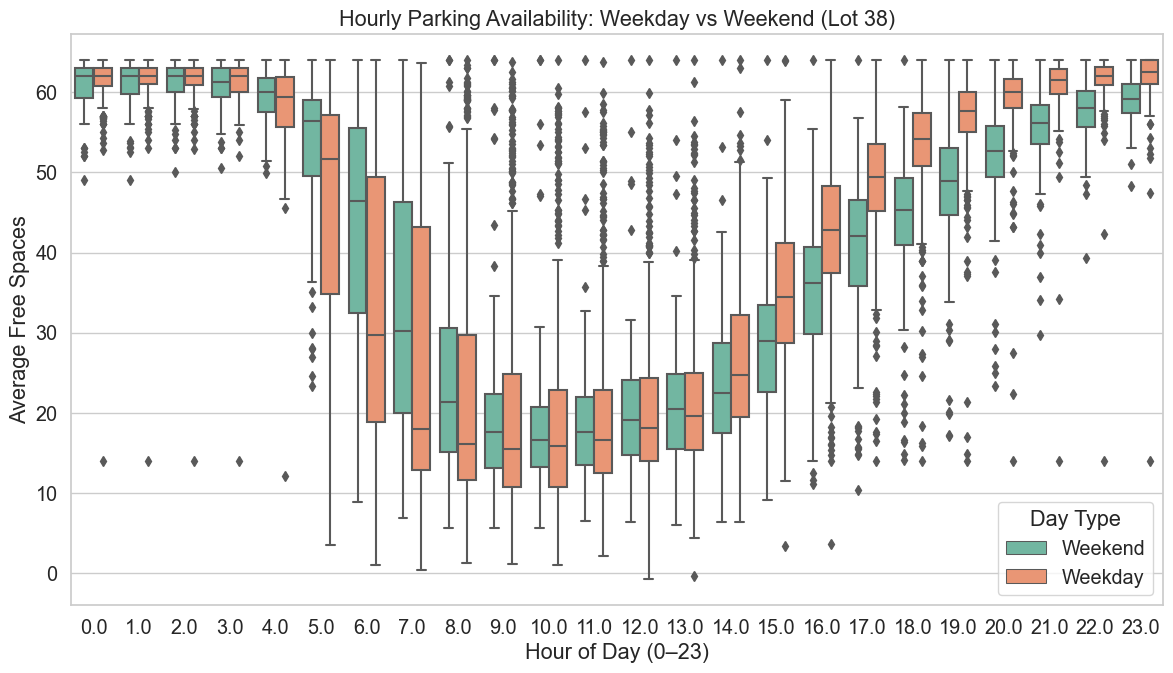

In [14]:
# Boxplots of avg_free_spaces grouped by day_of_week (Mon–Sun), split by weekday/weekend for Lot 38
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.set(style="whitegrid", font_scale=1.3)

# Create a new column for weekday/weekend
weekday_map = {0: 'Weekday', 1: 'Weekday', 2: 'Weekday', 3: 'Weekday', 4: 'Weekday', 5: 'Weekend', 6: 'Weekend'}
df['weekday_type'] = df['day_of_week'].map(weekday_map)

# Boxplot: avg_free_spaces by hour_of_day, split by weekday/weekend
sns.boxplot(x='hour_of_day', y='avg_free_spaces', hue='weekday_type', data=df, palette='Set2')
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Average Free Spaces')
plt.title('Hourly Parking Availability: Weekday vs Weekend (Lot 38)')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()



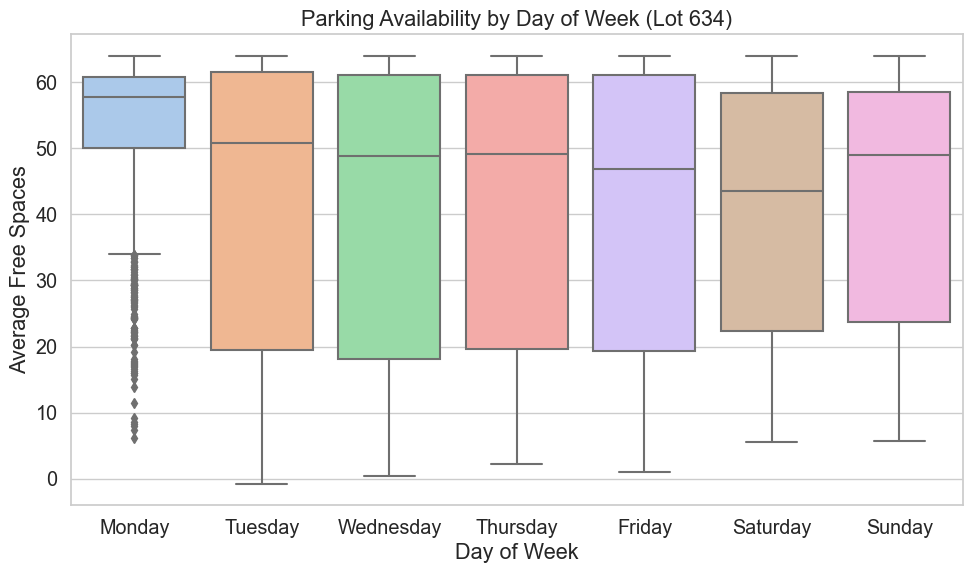

In [15]:
# Convert day_of_week numbers to names for boxplot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['weekday_name_fixed'] = df['day_of_week'].map(day_map)
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday_name_fixed'] = pd.Categorical(df['weekday_name_fixed'], categories=order, ordered=True)
sns.boxplot(x='weekday_name_fixed', y='avg_free_spaces', data=df, palette='pastel')
plt.xlabel('Day of Week')
plt.ylabel('Average Free Spaces')
plt.title('Parking Availability by Day of Week (Lot 634)')
plt.tight_layout()
plt.show()